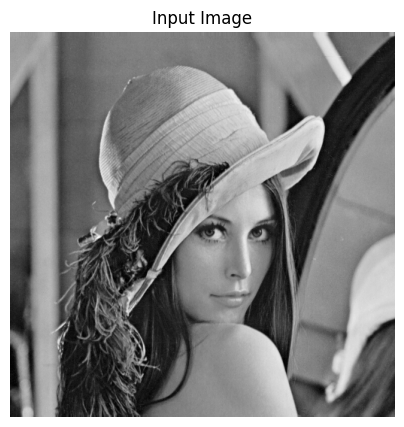

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('input.png', cv2.IMREAD_GRAYSCALE)

# Synthetic fallback if image is missing
if img is None:
    img = np.zeros((300, 300), dtype=np.uint8)
    cv2.rectangle(img, (40, 40), (120, 260), 200, -1) # Vertical rect
    cv2.rectangle(img, (150, 80), (250, 150), 150, -1) # Horizontal rect
    for i in range(0, 300, 20):
        cv2.line(img, (i, 0), (i, 300), 100, 1) # Vertical lines (texture)

img_float = img.astype(np.float32) / 255.0

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

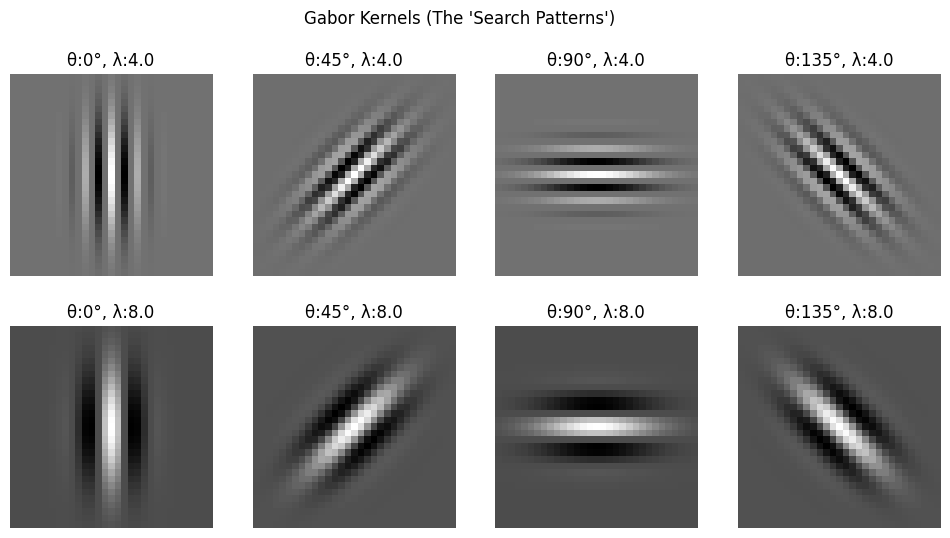

In [5]:
def get_gabor_bank():
    kernels = []
    # Orientations: 0, 45, 90, 135 degrees
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    # Wavelengths: Small (fine detail) to Large (broad edges)
    lambdas = [4.0, 8.0] 
    
    sigma = 3.0
    gamma = 0.5
    psi = 0
    
    for lambd in lambdas:
        for theta in thetas:
            kern = cv2.getGaborKernel((31, 31), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
            kernels.append((kern, theta, lambd))
    return kernels

kernels_data = get_gabor_bank()

# Visualize the kernels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, (kern, theta, lambd) in enumerate(kernels_data):
    ax = axes[i // 4, i % 4]
    ax.imshow(kern, cmap='gray')
    ax.set_title(f"θ:{int(np.degrees(theta))}°, λ:{lambd}")
    ax.axis('off')
plt.suptitle("Gabor Kernels (The 'Search Patterns')")
plt.show()

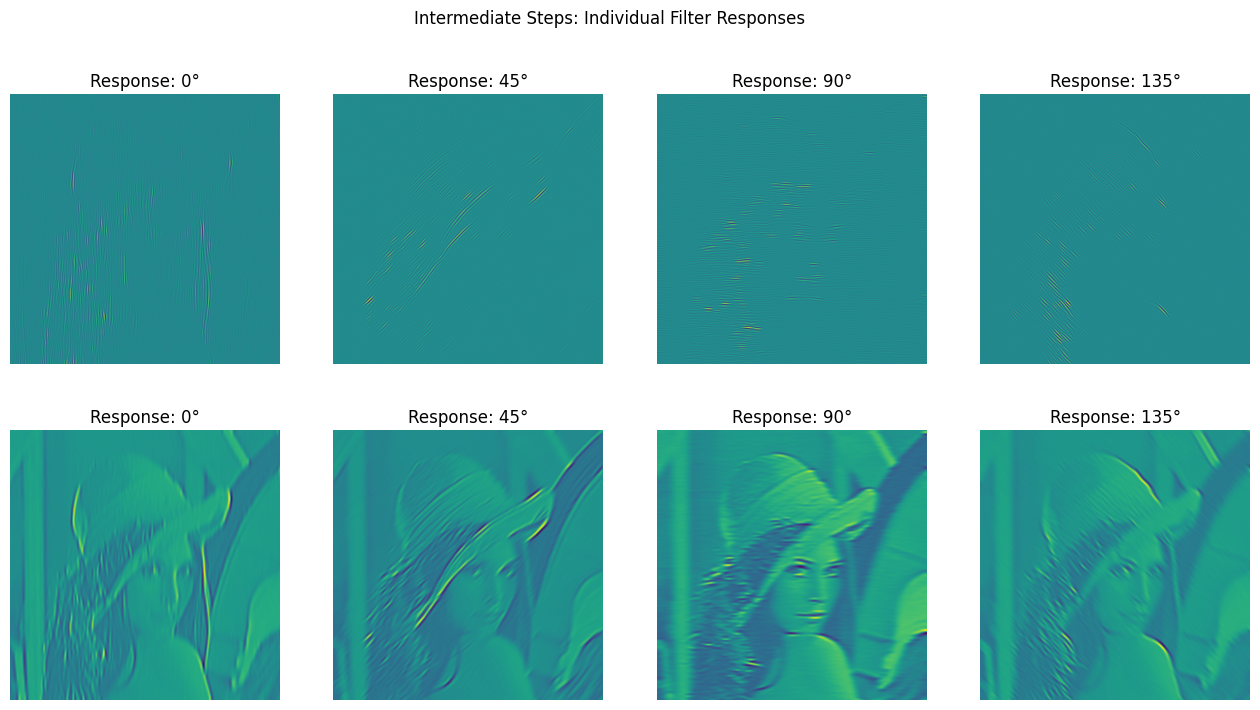

In [6]:
responses = []
composite_map = np.zeros_like(img_float)

for kern, theta, lambd in kernels_data:
    # Apply the filter
    fimg = cv2.filter2D(img_float, cv2.CV_32F, kern)
    responses.append(fimg)
    
    # Update composite map: keep the maximum intensity found so far
    np.maximum(composite_map, fimg, composite_map)

# Visualize individual responses
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, res in enumerate(responses):
    ax = axes[i // 4, i % 4]
    ax.imshow(res, cmap='viridis')
    theta_deg = int(np.degrees(kernels_data[i][1]))
    ax.set_title(f"Response: {theta_deg}°")
    ax.axis('off')
plt.suptitle("Intermediate Steps: Individual Filter Responses")
plt.show()

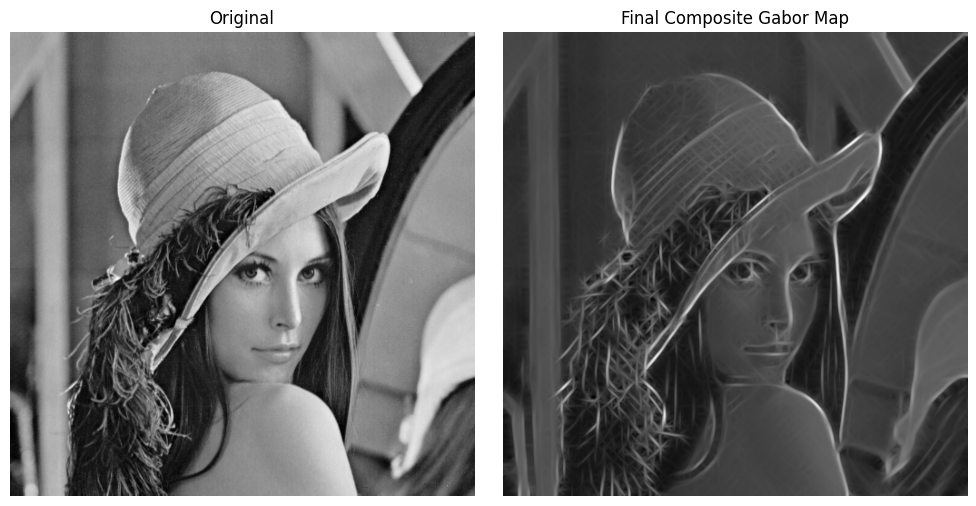

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
# Using 'magma' or 'inferno' colormap makes edges pop
plt.imshow(composite_map, cmap='gray')
plt.title("Final Composite Gabor Map")
plt.axis('off')

plt.tight_layout()
plt.show()